In [1]:
import numpy as np
import pytest
import pyccl as ccl
from pyccl import CCLWarning

from pyccl.pk2d import Pk2D
from pyccl.correlations import correlation

import matplotlib
import matplotlib.pyplot as plt

In [2]:
#set up cosmology

COSMO = ccl.Cosmology(
    Omega_c=0.26507647072945384,
    Omega_b=0.0495,
    Omega_k=0,
    h=0.6732,
    w0=-1,
    wa=0,
    A_s=2.1/1e9,
    n_s=0.96605,
    m_nu=0.06,
    Neff=3.046,
    mass_split='single',
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',
    extra_parameters = {"camb": {"halofit_version": "takahashi",
                                 'AccuracyBoost': 1.0,
                                 'kmax':15,
                                 'dark_energy_model': 'ppf',
                                 'accurate_massive_neutrino_transfer': False,
                                 'k_per_logint': 15,
                                 }}
    )
h=0.6732

#set up lens and source sample

srcs_nzs = np.loadtxt('./cocoa/Cocoa/projects/roman_fourier/data/fiducial.nz')
lens_nzs = np.loadtxt('./cocoa/Cocoa/projects/roman_fourier/data/lsst_lens_4cosmolike.nz')

z_srcs = srcs_nzs[:,0]+0.005
srcs_nz = srcs_nzs[:,1:]
z_lens = lens_nzs[:,0]+0.005
lens_nz = lens_nzs[:,1:]

srcs = []
lens = []
nsrcs = 8
nlens = 10
gbias =  [1.09,1.15,1.21,1.27,1.33,1.40,1.46,1.53,1.60,1.67]
ggl_exclude = []

for i in range(nsrcs):
    srcs.append(ccl.WeakLensingTracer(COSMO, dndz=(z_srcs, srcs_nz[:,i]), has_shear=True, n_samples=400))
for i in range(nlens):
    lens.append(ccl.NumberCountsTracer(COSMO, dndz=(z_lens, lens_nz[:,i]), bias=(z_lens,np.ones_like(z_lens)*gbias[i]), has_rsd=False, n_samples=400))

### Lensing Efficiency

from CCL's paper the lensing kernel is 

$\tilde{\Delta}_\ell^\mathrm{L} = \frac{3}{2}\Omega_{M,0}H_0^2\sqrt{\frac{(\ell+2)!}{(\ell-2)!}}\frac{1}{k^2}\frac{1+z_\ell}{\chi_\ell}W^L(z_\ell)$

where

$W^L(z) \equiv \int_z^\infty dz' p_z(z') \frac{r(\chi'-\chi)}{r(\chi')r(\chi)}$

function get_lensing_kernel actual output is 

$W(\chi) = \frac{3H_0^2\Omega_m}{2a}\chi\int_{z(\chi)}^\infty dz (1-\frac{5s(z)}{z})\frac{\chi(z)-\chi}{\chi(z)}$

which is equivalent to $\tilde{\Delta}_\ell^\mathrm{L}$ without the $\ell$ prefactor

- CCL: When use the get_kernel function, it calculates the kernel over the z-grid of redshift distribution. Meanwhie, when the tracer is created, a spline table of kernel is built based on the z-grid of redshift distribution. Later on, when it calculates the power spectrum, no matter what methods they use, either GSL or spline, its internal precsion based on the spline table of kernel is already determined.

- CosmoLike: It builds a interpolation table for lensing efficiency based on a grid of scale factor which devides a=[0,1] into 225 (in my setup) cells, and the integration is done by GSL.


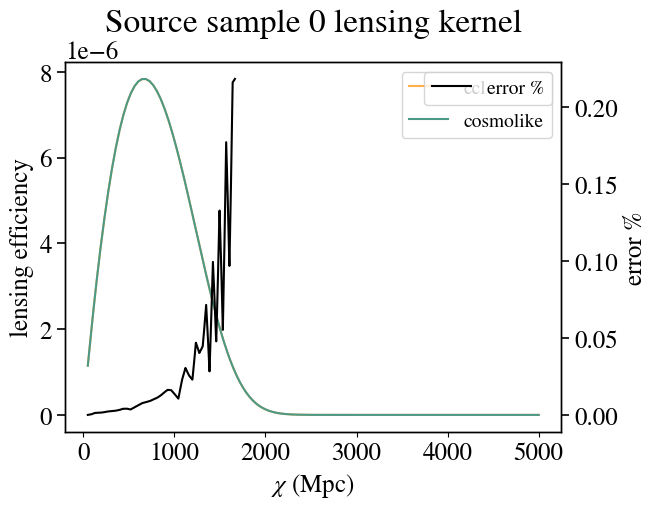

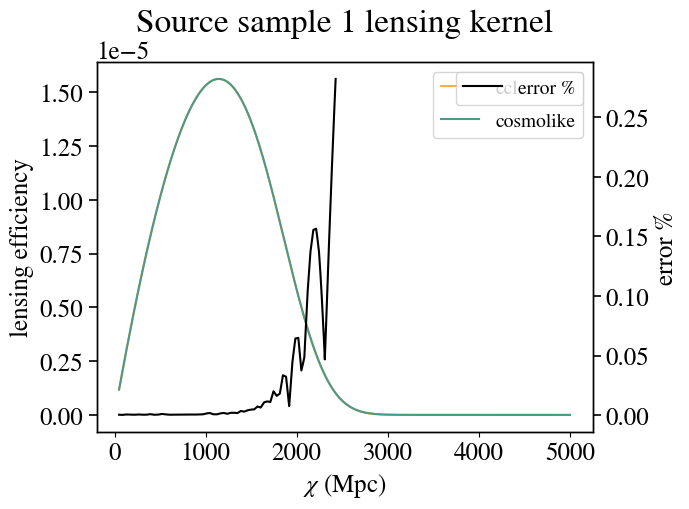

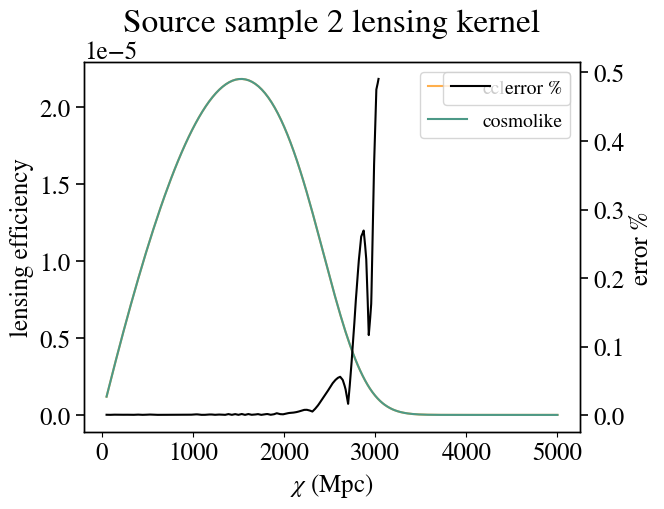

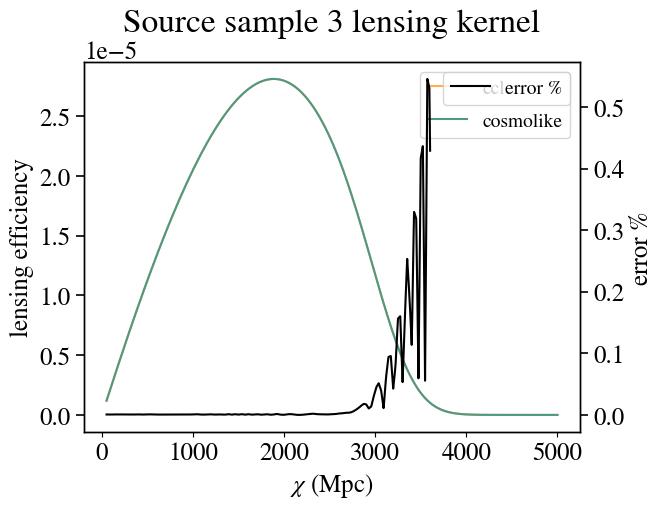

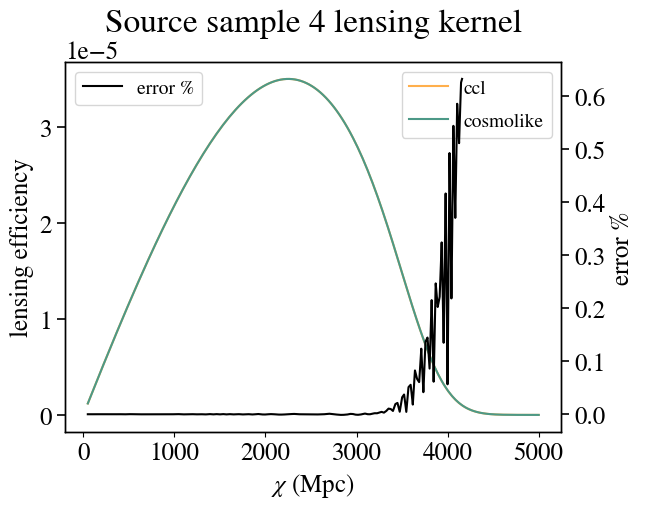

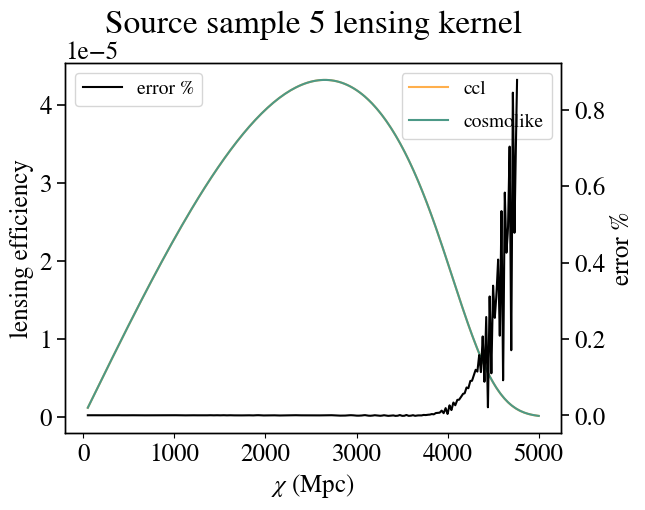

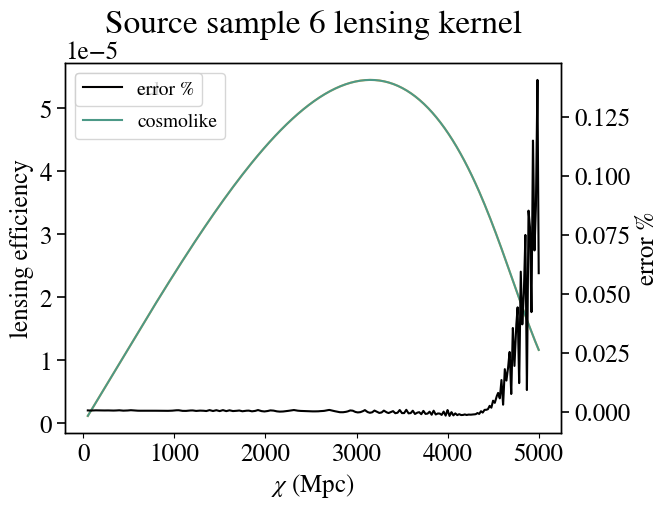

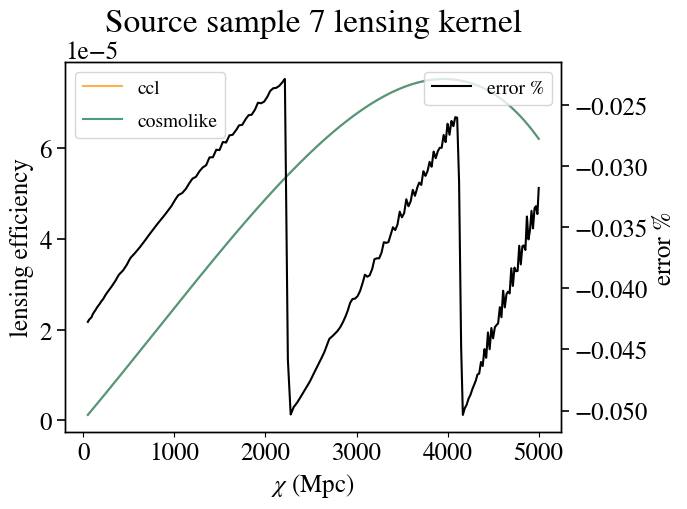

In [13]:
from scipy.interpolate import interp1d
filepath = './cocoa/Cocoa/projects/roman_fourier/chains/roman_setup0_evaluate/'
chis_cosmolike = np.loadtxt(filepath+'chi_of_lensing_efficiency.txt')
kernel_cosmolike = np.loadtxt(filepath+'lensing_efficiency.txt')
chis = np.linspace(50, 5000, 5000)

for i in range(nsrcs):
    
    chis_ccl = srcs[i].get_kernel()[1][0]
    kernel_ccl = srcs[i].get_kernel()[0][0]
    f_ccl = interp1d(chis_ccl, kernel_ccl)
    f_cosmolike = interp1d(chis_cosmolike, kernel_cosmolike[i,:])

    ys_ccl = f_ccl(chis)
    ys_cosmolike = f_cosmolike(chis)

    fig, ax1 = plt.subplots()
    ax1.plot(chis, ys_ccl, color='#FFAF4C', label='ccl')
    ax1.plot(chis, ys_cosmolike, color='#4C9987', label='cosmolike')
    ax1.set_ylabel('lensing efficiency')
    ax1.set_xlabel(r'$\chi$ (Mpc)')
    ax1.legend()
        
    ax2 = ax1.twinx()
    greater0 = (ys_ccl>1e-6)
    ax2.plot(chis[greater0], (ys_cosmolike[greater0]-ys_ccl[greater0])/ys_ccl[greater0]*100, color='k', label='error %')
    ax2.set_ylabel('error %')
    ax2.legend()

    plt.title(f'Source sample {i} lensing kernel')
    plt.show()

### Conclusion

It is little difficult to say where the strange error comes from when the curve goes down to 0. And why the last tomobin's error has a different behaviours. The error can reach 0.2% sometimes where the amplitude of signal is still not small, so it may be valuable to inpsect inside this part to see what happened.

### Modification
No modification here.

In [10]:
# GENERAL PLOT OPTIONS
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['ytick.major.size'] = 6
matplotlib.rcParams['ytick.major.width'] = 1.2
matplotlib.rcParams['ytick.minor.size'] = 3
matplotlib.rcParams['ytick.minor.width'] = 0.8
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 24
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['legend.fontsize'] = 14
matplotlib.rcParams['legend.title_fontsize'] = 18
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.dpi'] = 300